## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [1]:
import pandas as pd
import geopandas as gpd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
from fuzzywuzzy import fuzz
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_ID = 'EL30'

In [3]:
dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2009_2023.csv", encoding = enc)
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2009-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.845785,5.512796,8.179290,10.845785,NaN,NaN,NaN,5.512796,NaN,NaN,NaN,8.179290,NaN,NaN,NaN,6.287515,92.499468,110.570164,194.474527,194.912970,892.266667,28.782796,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.0,1.000000,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.000000,79.730978,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.000000,21.863192,22,9,20,13,13,10,8,9,2,1.978000,14.480667,194.912970,0,19.000000,19.166667,42.592593,920.721061,45.0,0.0,45.0,8.333333,30.666667,30.666667,8.333333,1230.0,227.0,9.0,72.351252,546.0,54.0,54.0,546.0,45632.0,201617.0,45952.0,293201.0,43321.0,220852.0,58521.0,322694.0,19823.63,NaN,NaN
1,2009-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.446903,7.663290,9.555097,11.446903,NaN,NaN,NaN,7.663290,NaN,NaN,NaN,9.555097,NaN,NaN,NaN,6.327663,92.557817,110.718959,196.157567,196.157567,1331.400000,42.948387,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,5369.544043,863.918625,1,124.980862,72.025314,168.746576,0.0,2.741869,9092.468792,3043.444411,5,157.020761,152.212002,180.041979,0.000000,9.259888,1549.348962,1081.112134,1.788854,12.696343,30.830096,4.405654,0.000000,2.978368,1,9,1,13,13,10,8,9,2,2.550000,16.206000,196.157567,0,20.791667,18.916667,42.992424,928.453830,46.0,2.0,44.0,9.833333,33.000000,33.000000,9.833333,1216.0,229.0,10.0,72.746381,538.0,55.0,55.0,538.0,39132.0,180473.0,33120.0,252725.0,36806.0,177964.0,43801.0,258571.0,7725.12,NaN,NaN
2,2009-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.370194,7.741384,9.555789,11.370194,NaN,NaN,NaN,7.744364,NaN,NaN,NaN,9.557279,NaN,NaN,NaN,6.287377,86.995064,105.730917,194.908674,194.908674,1227.100000,39.583871,7451.460209,1907.131239,7.200000,218.497003,207.330391,190.939862,0.000000,2.773017,5491.611975,467.065216,3,162.183002,68.022695,183.011169,0.0,1.000000,9901.346815,4576.388472,14,257.169814,553.363377,208.832872,0.000000,5.152035,1461.964111,1273.662642,4.211096,30.940738,139.781885,8.039500,0.000000,1.621831,1,9,1,13,13,10,8,9,2,4.784000,15.404000,194.908674,0,19.875000,18.250000,43.452381,879.081390,44.0,2.0,42.0,9.833333,31.333333,31.333333,9.833333,1175

<AxesSubplot:>

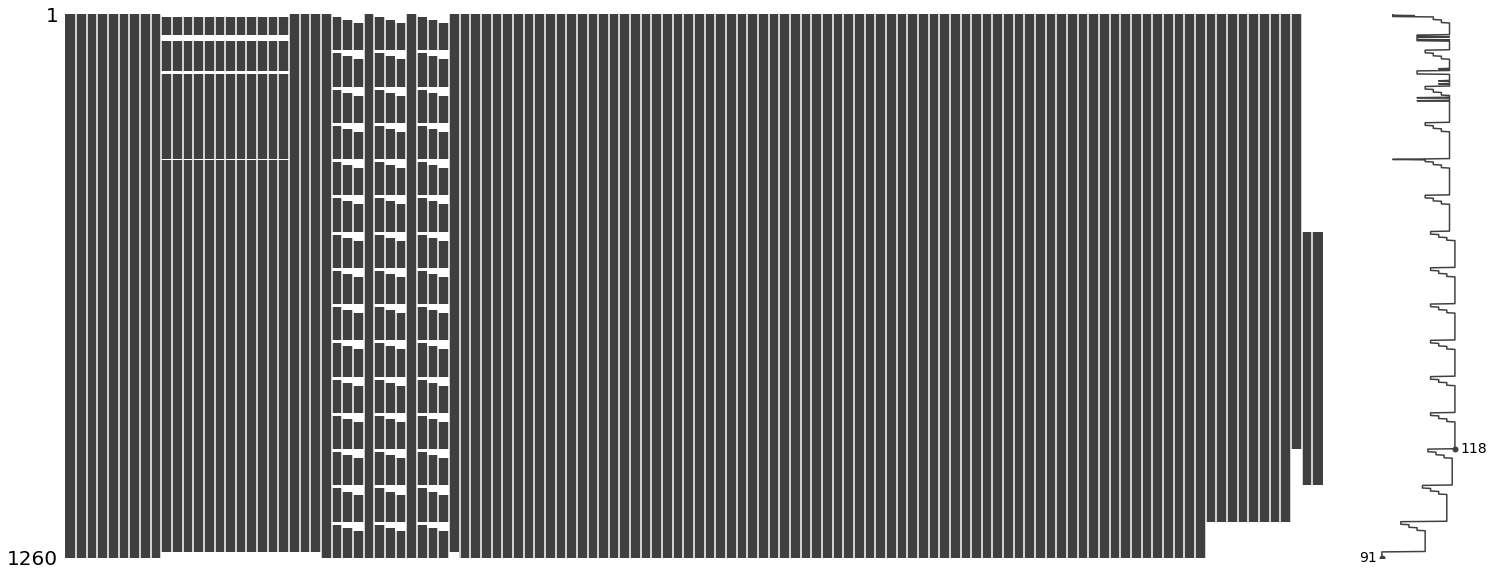

In [4]:
missingno.matrix(dataset_monthly)

In [5]:
missing = describe_dataframe(dataset_monthly, remove_zeros=True)
missing

,Column,Missing
0,ndvi,3.7302
1,ndmi,3.7302
2,ndwi,3.7302
3,ndbi,3.7302
4,ndvi_mean,3.4127
...,...,...
31,F_Y_GE65,6.6667
32,F_TOTAL,6.6667
33,MIO_EUR,20.0000
34,L_TOTAL,53.3333


In [6]:
years = dataset_monthly.year.unique()
nuts3_units = dataset_monthly.NUTS3_NAME.unique()

In [7]:
data = []

for year in years:
    for region in nuts3_units:
        filtered_df = dataset_monthly.loc[(dataset_monthly['year'] == year) & (dataset_monthly['NUTS3_NAME'] == region)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        q1_df = filtered_df.loc[(filtered_df['month'] <= 3)]
        q2_df = filtered_df.loc[(filtered_df['month'] <= 6)]
        q3_df = filtered_df.loc[(filtered_df['month'] <= 9)]
        q4_df = filtered_df.loc[(filtered_df['month'] <= 12)]

        min_temp_q1 = q1_df['lst_mean'].min()
        mean_temp_q1 = q1_df['lst_mean'].mean()
        max_temp_q1 = q1_df['lst_mean'].max()
        prec_q1 = q1_df['rainfall_mean'].sum()

        ndvi_q1 = q1_df['ndvi'].mean()
        ndwi_q1 = q1_df['ndwi'].mean()
        ndmi_q1 = q1_df['ndmi'].mean()
        ndbi_q1 = q1_df['ndbi'].mean()

        ndvi_mean_q1 = q1_df['ndvi_mean'].mean()
        ndwi_mean_q1 = q1_df['ndwi_mean'].mean()
        ndmi_mean_q1 = q1_df['ndmi_mean'].mean()
        ndbi_mean_q1 = q1_df['ndbi_mean'].mean()

        ndvi_std_q1 = q1_df['ndvi_std'].mean()
        ndwi_std_q1 = q1_df['ndwi_std'].mean()
        ndmi_std_q1 = q1_df['ndmi_std'].mean()
        ndbi_std_q1 = q1_df['ndbi_std'].mean()

        min_temp_q2 = q2_df['lst_mean'].min()
        mean_temp_q2 = q2_df['lst_mean'].mean()
        max_temp_q2 = q2_df['lst_mean'].max()
        prec_q2 = q2_df['rainfall_mean'].sum()

        ndvi_q2 = q2_df['ndvi'].mean()
        ndwi_q2 = q2_df['ndwi'].mean()
        ndmi_q2 = q2_df['ndmi'].mean()
        ndbi_q2 = q2_df['ndbi'].mean()

        ndvi_mean_q2 = q2_df['ndvi_mean'].mean()
        ndwi_mean_q2 = q2_df['ndwi_mean'].mean()
        ndmi_mean_q2 = q2_df['ndmi_mean'].mean()
        ndbi_mean_q2 = q2_df['ndbi_mean'].mean()

        ndvi_std_q2 = q2_df['ndvi_std'].mean()
        ndwi_std_q2 = q2_df['ndwi_std'].mean()
        ndmi_std_q2 = q2_df['ndmi_std'].mean()
        ndbi_std_q2 = q2_df['ndbi_std'].mean()

        min_temp_q3 = q3_df['lst_mean'].min()
        mean_temp_q3 = q3_df['lst_mean'].mean()
        max_temp_q3 = q3_df['lst_mean'].max()
        prec_q3 = q3_df['rainfall_mean'].sum()

        ndvi_q3 = q3_df['ndvi'].mean()
        ndwi_q3 = q3_df['ndwi'].mean()
        ndmi_q3 = q3_df['ndmi'].mean()
        ndbi_q3 = q3_df['ndbi'].mean()

        ndvi_mean_q3 = q3_df['ndvi_mean'].mean()
        ndwi_mean_q3 = q3_df['ndwi_mean'].mean()
        ndmi_mean_q3 = q3_df['ndmi_mean'].mean()
        ndbi_mean_q3 = q3_df['ndbi_mean'].mean()

        ndvi_std_q3 = q3_df['ndvi_std'].mean()
        ndwi_std_q3 = q3_df['ndwi_std'].mean()
        ndmi_std_q3 = q3_df['ndmi_std'].mean()
        ndbi_std_q3 = q3_df['ndbi_std'].mean()

        min_temp_q4 = q4_df['lst_mean'].min()
        mean_temp_q4 = q4_df['lst_mean'].mean()
        max_temp_q4 = q4_df['lst_mean'].max()
        prec_q4 = q4_df['rainfall_mean'].sum()

        ndvi_q4 = q4_df['ndvi'].mean()
        ndwi_q4 = q4_df['ndwi'].mean()
        ndmi_q4 = q4_df['ndmi'].mean()
        ndbi_q4 = q4_df['ndbi'].mean()

        ndvi_mean_q4 = q4_df['ndvi_mean'].mean()
        ndwi_mean_q4 = q4_df['ndwi_mean'].mean()
        ndmi_mean_q4 = q4_df['ndmi_mean'].mean()
        ndbi_mean_q4 = q4_df['ndbi_mean'].mean()

        ndvi_std_q4 = q4_df['ndvi_std'].mean()
        ndwi_std_q4 = q4_df['ndwi_std'].mean()
        ndmi_std_q4 = q4_df['ndmi_std'].mean()
        ndbi_std_q4 = q4_df['ndbi_std'].mean()

        data.append({'NUTS3_NAME': region, 
                     'year': year, 
                     'min_temp_q1': min_temp_q1,
                     'mean_temp_q1': mean_temp_q1,
                     'max_temp_q1': max_temp_q1,
                     'prec_q1': prec_q1,
                     'ndvi_q1': ndvi_q1,
                     'ndwi_q1': ndwi_q1,
                     'ndmi_q1': ndmi_q1,
                     'ndbi_q1': ndbi_q1,
                     'ndvi_mean_q1': ndvi_mean_q1,
                     'ndwi_mean_q1': ndwi_mean_q1,
                     'ndmi_mean_q1': ndmi_mean_q1,
                     'ndbi_mean_q1': ndbi_mean_q1,
                     'ndvi_std_q1': ndvi_std_q1,
                     'ndwi_std_q1': ndwi_std_q1,
                     'ndmi_std_q1': ndmi_std_q1,
                     'ndbi_std_q1': ndbi_std_q1,
                     'min_temp_q2': min_temp_q2,
                     'mean_temp_q2': mean_temp_q2,
                     'max_temp_q2': max_temp_q2,
                     'prec_q2': prec_q2,
                     'ndvi_q2': ndvi_q2,
                     'ndwi_q2': ndwi_q2,
                     'ndmi_q2': ndmi_q2,
                     'ndbi_q2': ndbi_q2,
                     'ndvi_mean_q2': ndvi_mean_q2,
                     'ndwi_mean_q2': ndwi_mean_q2,
                     'ndmi_mean_q2': ndmi_mean_q2,
                     'ndbi_mean_q2': ndbi_mean_q2,
                     'ndvi_std_q2': ndvi_std_q2,
                     'ndwi_std_q2': ndwi_std_q2,
                     'ndmi_std_q2': ndmi_std_q2,
                     'ndbi_std_q2': ndbi_std_q2,
                     'min_temp_q3': min_temp_q3,
                     'mean_temp_q3': mean_temp_q3,
                     'max_temp_q3': max_temp_q3,
                     'prec_q3': prec_q3,
                     'ndvi_q3': ndvi_q3,
                     'ndwi_q3': ndwi_q3,
                     'ndmi_q3': ndmi_q3,
                     'ndbi_q3': ndbi_q3,
                     'ndvi_mean_q3': ndvi_mean_q3,
                     'ndwi_mean_q3': ndwi_mean_q3,
                     'ndmi_mean_q3': ndmi_mean_q3,
                     'ndbi_mean_q3': ndbi_mean_q3,
                     'ndvi_std_q3': ndvi_std_q3,
                     'ndwi_std_q3': ndwi_std_q3,
                     'ndmi_std_q3': ndmi_std_q3,
                     'ndbi_std_q3': ndbi_std_q3,
                     'min_temp_q4': min_temp_q4,
                     'mean_temp_q4': mean_temp_q4,
                     'max_temp_q4': max_temp_q4,
                     'prec_q4': prec_q4,
                     'ndvi_q4': ndvi_q4,
                     'ndwi_q4': ndwi_q4,
                     'ndmi_q4': ndmi_q4,
                     'ndbi_q4': ndbi_q4,
                     'ndvi_mean_q4': ndvi_mean_q4,
                     'ndwi_mean_q4': ndwi_mean_q4,
                     'ndmi_mean_q4': ndmi_mean_q4,
                     'ndbi_mean_q4': ndbi_mean_q4,
                     'ndvi_std_q4': ndvi_std_q4,
                     'ndwi_std_q4': ndwi_std_q4,
                     'ndmi_std_q4': ndmi_std_q4,
                     'ndbi_std_q4': ndbi_std_q4})
        
q_df = pd.DataFrame(data)        

In [8]:
q_df

,NUTS3_NAME,year,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,βορειος τομεας αθηνων,2009,8.138262,9.369808,11.791871,15.550150,0.235448,-0.150954,0.087188,-0.087188,0.241873,-0.154813,0.090104,-0.090104,0.029572,0.024510,0.021811,0.021811,8.138262,16.210765,29.034511,18.917281,0.241532,-0.175401,0.079958,-0.079958,0.247854,-0.179053,0.082640,-0.082640,0.027673,0.025038,0.021026,0.021026,8.138262,20.140141,30.403699,24.716439,0.239516,-0.182541,0.074270,-0.074270,0.244450,-0.186123,0.075879,-0.075879,0.027181,0.025545,0.021346,0.021346,8.138262,18.868279,30.403699,40.623698,0.237581,-0.146952,0.092324,-0.092324,0.239178,-0.152264,0.089627,-0.089627,0.029313,0.028778,0.023733,0.023733
1,δυτικος τομεας αθηνων,2009,9.087571,10.649126,13.304710,15.055505,0.100402,-0.069015,0.055988,-0.055988,0.107657,-0.096047,0.037917,-0.037917,0.024924,0.017246,0.012508,0.012508,9.087571,17.822192,30.647333,18.445123,0.114947,-0.124903,0.027757,-0.027757,0.124381,-0.138127,0.021919,-0.021919,0.025600,0.019399,0.012721,0.012721,9.087571,21.801058,32.734903,24.425173,0.114715,-0.134871,0.020196,-0.020196,0.123208,-0.146217,0.015426,-0.015426,0.024121,0.018960,0.011948,0.011948,9.087571,20.480382,32.734903,40.099282,0.115429,-0.109760,0.034417,-0.034417,0.126113,-0.119895,0.032468,-0.032468,0.030257,0.021799,0.014913,0.014913
2,κεντρικος τομεας αθηνων,2009,8.625750,10.220964,12.481355,15.165764,0.145600,-0.038342,0.096487,-0.096487,0.143736,-0.038197,0.097809,-0.097809,0.043064,0.038645,0.034905,0.034905,8.625750,17.153384,29.668000,18.365675,0.174500,-0.101510,0.075459,-0.075459,0.170333,-0.101060,0.074662,-0.074662,0.042241,0.031274,0.031653,0.031653,8.625750,20.943380,31.373581,23.803638,0.171466,-0.114438,0.064271,-0.064271,0.169508,-0.113851,0.065345,-0.065345,0.041326,0.029729,0.030198,0.030198,8.625750,19.688437,31.373581,38.818634,0.178480,-0.076577,0.089578,-0.089578,0.173559,-0.082365,0.084226,-0.084226,0.042632,0.032351,0.031550,0.031550
3,νοτιος τομεας αθηνων,2009,8.821684,10.476276,12.591198,15.201951,0.146219,-0.069656,0.083541,-0.083541,0.161045,-0.075872,0.090722,-0.090722,0.029778,0.024400,0.015964,0.015964,8.821684,17.194929,29.539952,18.361252,0.163160,-0.134094,0.053837,-0.053837,0.168643,-0.135850,0.057454,-0.057454,0.029447,0.023712,0.016459,0.016459,8.821684,20.999032,31.255668,23.438053,0.160182,-0.145848,0.042792,-0.042792,0.164685,-0.146553,0.046842,-0.046842,0.028086,0.024088,0.017858,0.017858,8.821684,19.771731,31.255668,38.175363,0.165003,-0.124682,0.057581,-0.057581,0.166144,-0.121025,0.062028,-0.062028,0.031513,0.030844,0.020480,0.020480
4,ανατολικη αττικη,2009,7.417383,8.652328,10.572397,15.554567,0.364639,-0.200595,0.137375,-0.137375,0.230903,0.085297,0.296490,-0.296490,0.024078,0.024325,0.021360,0.021360,7.417383,15.198867,27.656567,19.033084,0.366286,-0.242100,0.117634,-0.117634,0.297351,-0.090697,0.200271,-0.200271,0.028822,0.026678,0.025596,0.025596,7.417383,19.288165,29.663207,24.699279,0.356923,-0.254688,0.100115,-0.100115,0.312404,-0.151691,0.158246,-0.158246,0.029623,0.025908,0.027263,0.027263,7.417383,18.178348,29.663207,40.658753,0.357092,-0.237458,0.106279,-0.106279,0.322395,-0.159835,0.149720,-0.149720,0.032287,0.031042,0.030822,0.030822
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [9]:
dataset_monthly = pd.merge(dataset_monthly, q_df,  how='left', on=['NUTS3_NAME', 'year'])

In [10]:
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2009-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.845785,5.512796,8.179290,10.845785,NaN,NaN,NaN,5.512796,NaN,NaN,NaN,8.179290,NaN,NaN,NaN,6.287515,92.499468,110.570164,194.474527,194.912970,892.266667,28.782796,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.0,1.000000,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.000000,79.730978,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.000000,21.863192,22,9,20,13,13,10,8,9,2,1.978000,14.480667,194.912970,0,19.000000,19.166667,42.592593,920.721061,45.0,0.0,45.0,8.333333,30.666667,30.666667,8.333333,1230.0,227.0,9.0,72.351252,546.0,54.0,54.0,546.0,45632.0,201617.0,45952.0,293201.0,43321.0,220852.0,58521.0,322694.0,19823.63,NaN,NaN,8.138262,9.369808,11.791871,15.550150,0.235448,-0.150954,0.087188,-0.087188,0.241873,-0.154813,0.090104,-0.090104,0.029572,0.024510,0.021811,0.021811,8.138262,16.210765,29.034511,18.917281,0.241532,-0.175401,0.079958,-0.079958,0.247854,-0.179053,0.082640,-0.082640,0.027673,0.025038,0.021026,0.021026,8.138262,20.140141,30.403699,24.716439,0.239516,-0.182541,0.074270,-0.074270,0.244450,-0.186123,0.075879,-0.075879,0.027181,0.025545,0.021346,0.021346,8.138262,18.868279,30.403699,40.623698,0.237581,-0.146952,0.092324,-0.092324,0.239178,-0.152264,0.089627,-0.089627,0.029313,0.028778,0.023733,0.023733
1,2009-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.446903,7.663290,9.555097,11.446903,NaN,NaN,NaN,7.663290,NaN,NaN,NaN,9.555097,NaN,NaN,NaN,6.327663,92.557817,110.718959,196.157567,196.157567,1331.400000,42.948387,7495.493496,2041.783345,2.800000,135

In [11]:
grouped_annualy = dataset_monthly.groupby(['year', 'NUTS2_ID',	'NUTS2_NAME',	'NUTS3_ID',	'NUTS3_NAME'], as_index = False)
dataset_annual = grouped_annualy.mean()
dataset_annual.head()

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2009,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,6.5,0.237581,0.092324,-0.146952,-0.092324,0.239178,0.089627,-0.152264,-0.089627,0.029313,0.023733,0.028778,0.023733,24.077932,13.658626,18.868279,10.845785,11.665333,17.146430,17.836965,5.512796,4.611190,6.437312,6.991166,8.179290,8.138262,11.791871,12.414066,3.385308,20.674325,34.982816,104.020769,648.519679,577.172222,18.934278,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,6975.099311,9.886334,2.0,158.038271,190.198124,179.915914,0.0,1.000000,15103.584543,3887.958042,14.0,242.913089,460.563721,193.437501,0.000000,79.730978,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.00000,21.863192,22.0,9.0,20.0,13.0,13.0,10.0,8.0,9.0,2.0,9.866889,28.994000,103.038655,0.0,19.000000,19.166667,42.592593,920.721061,45.0,0.0,45.0,8.333333,30.666667,30.666667,8.333333,1230.0,227.0,9.0,72.351252,546.0,54.0,54.0,546.0,45632.0,201617.0,45952.0,293201.0,43321.0,220852.0,58521.0,322694.0,19823.63,NaN,NaN,8.138262,9.369808,11.791871,15.550150,0.235448,-0.150954,0.087188,-0.087188,0.241873,-0.154813,0.090104,-0.090104,0.029572,0.024510,0.021811,0.021811,8.138262,16.210765,29.034511,18.917281,0.241532,-0.175401,0.079958,-0.079958,0.247854,-0.179053,0.082640,-0.082640,0.027673,0.025038,0.021026,0.021026,8.138262,20.140141,30.403699,24.716439,0.239516,-0.182541,0.074270,-0.074270,0.244450,-0.186123,0.075879,-0.075879,0.027181,0.025545,0.021346,0.021346,8.138262,18.868279,30.403699,40.623698,0.237581,-0.146952,0.092324,-0.092324,0.239178,-0.152264,0.089627,-0.089627,0.029313,0.028778,0.023733,0.023733
1,2009,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,6.5,0.115429,0.034417,-0.109760,-0.034417,0.126113,0.032468,-0.119895,-0.032468,0.030257,0.014913,0.021799,0.014913,25.352940,15.607823,20.48

In [12]:
grouped_annualy_cases = dataset_monthly.groupby(['year', 'NUTS2_ID',	'NUTS2_NAME',	'NUTS3_ID',	'NUTS3_NAME'], as_index = False)
dataset_annual_cases = grouped_annualy_cases.sum()
dataset_annual_cases.head()

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2009,EL30,αττικη,EL301,βορειος τομεας αθηνων,285.900960,456.671648,78,2.138231,0.830917,-1.322569,-0.830917,2.152602,0.806643,-1.370374,-0.806643,0.263815,0.213597,0.259005,0.213597,288.935187,163.903513,226.419350,130.149419,128.318667,171.464301,160.532685,66.153548,50.723095,64.373118,62.920495,98.151484,89.520881,117.918710,111.726590,40.623698,248.091898,419.793795,1248.249232,7782.236149,6926.066667,227.211331,151154.080222,19839.123335,84.800000,2395.842236,3522.185144,2233.969979,0.000000,135.841180,83701.191738,118.636004,24,1896.459252,2282.377488,2158.990973,0.0,12.000000,181243.014516,46655.496509,168,2914.957072,5526.764656,2321.250018,0.000000,956.771730,27557.476975,14213.191303,56.187441,286.493484,1110.337433,44.017169,0.000000,262.358310,264,108,240,156,156,120,96,108,24,118.402667,347.928000,1236.463865,0,228.0,230.0,511.111111,11048.652736,540.0,0.0,540.0,100.0,368.0,368.0,100.0,14760.0,2724.0,108.0,868.215026,6552.0,648.0,648.0,6552.0,547584.0,2419404.0,551424.0,3518412.0,519852.0,2650224.0,702252.0,3872328.0,237883.56,0.0,0.0,97.659143,112.437693,141.502452,186.601803,2.825379,-1.811445,1.046257,-1.046257,2.902471,-1.857758,1.081246,-1.081246,0.354863,0.294118,0.261733,0.261733,97.659143,194.529178,348.414133,227.007377,2.898383,-2.104810,0.959498,-0.959498,2.974248,-2.148638,0.991676,-0.991676,0.332080,0.300461,0.252314,0.252314,97.659143,241.681689,364.844387,296.597271,2.874192,-2.190495,0.891237,-0.891237,2.933402,-2.233478,0.910551,-0.910551,0.326173,0.306539,0.256156,0.256156,97.659143,226.419350,364.844387,487.484381,2.850975,-1.763426,1.107889,-1.107889,2.870136,-1.827165,1.075524,-1.075524,0.351753,0.345341,0.284795,0.284795
1,2009,EL30,αττικη,EL302,δυτικος τομεας αθηνων,284.238024,456.298728,78,1.038864,0.309754,-0.987840,-0.309754,1.135014,0.292213,-1.079056,-0.2922

In [13]:
dataset_annual.drop(columns=['month'], inplace=True)
print(dataset_annual.shape)

(105, 180)


In [14]:
dataset_annual['cases'] = dataset_annual_cases['cases']
dataset_annual['mosq_pred_mean'] = dataset_annual_cases['mosq_pred_mean']

<AxesSubplot:>

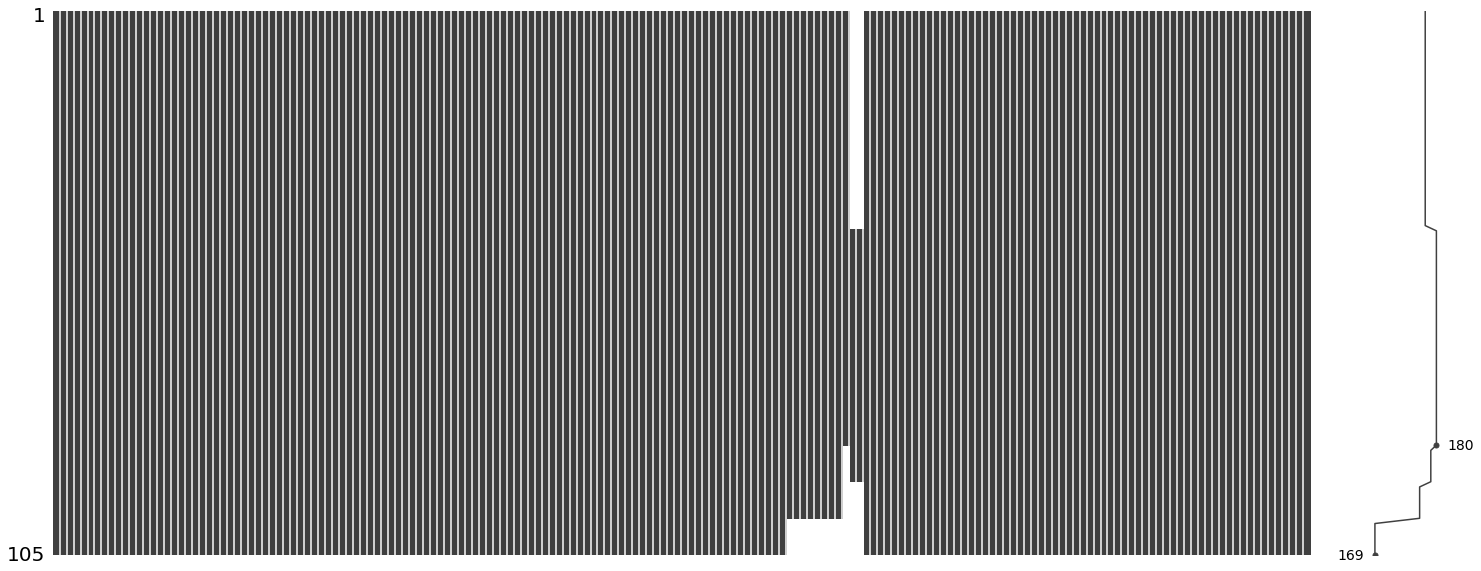

In [15]:
missingno.matrix(dataset_annual)

In [16]:
missing = describe_dataframe(dataset_annual, remove_zeros=True)
missing

,Column,Missing
0,M_Y_LT15,6.6667
1,M_Y15-64,6.6667
2,M_Y_GE65,6.6667
3,M_TOTAL,6.6667
4,F_Y_LT15,6.6667
5,F_Y15-64,6.6667
6,F_Y_GE65,6.6667
7,F_TOTAL,6.6667
8,MIO_EUR,20.0000
9,L_TOTAL,53.3333


In [17]:
dataset_annual.head(15)

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2009,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,0.237581,0.092324,-0.146952,-0.092324,0.239178,0.089627,-0.152264,-0.089627,0.029313,0.023733,0.028778,0.023733,24.077932,13.658626,18.868279,10.845785,11.665333,17.146430,17.836965,5.512796,4.611190,6.437312,6.991166,8.179290,8.138262,11.791871,12.414066,3.385308,20.674325,34.982816,104.020769,648.519679,577.172222,227.211331,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,6975.099311,9.886334,2.0,158.038271,190.198124,179.915914,0.0,1.000000,15103.584543,3887.958042,14.0,242.913089,460.563721,193.437501,0.000000,79.730978,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.000000,21.863192,22.0,9.0,20.0,13.0,13.0,10.0,8.0,9.0,2.0,9.866889,28.994000,103.038655,0,19.000000,19.166667,42.592593,920.721061,45.0,0.0,45.0,8.333333,30.666667,30.666667,8.333333,1230.0,227.0,9.0,72.351252,546.0,54.0,54.0,546.0,45632.0,201617.0,45952.0,293201.0,43321.0,220852.0,58521.0,322694.0,19823.63,NaN,NaN,8.138262,9.369808,11.791871,15.550150,0.235448,-0.150954,0.087188,-0.087188,0.241873,-0.154813,0.090104,-0.090104,0.029572,0.024510,0.021811,0.021811,8.138262,16.210765,29.034511,18.917281,0.241532,-0.175401,0.079958,-0.079958,0.247854,-0.179053,0.082640,-0.082640,0.027673,0.025038,0.021026,0.021026,8.138262,20.140141,30.403699,24.716439,0.239516,-0.182541,0.074270,-0.074270,0.244450,-0.186123,0.075879,-0.075879,0.027181,0.025545,0.021346,0.021346,8.138262,18.868279,30.403699,40.623698,0.237581,-0.146952,0.092324,-0.092324,0.239178,-0.152264,0.089627,-0.089627,0.029313,0.028778,0.023733,0.023733
1,2009,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,0.115429,0.034417,-0.109760,-0.034417,0.126113,0.032468,-0.119895,-0.032468,0.030257,0.014913,0.021799,0.014913,25.352940,15.607823,20.480382,11.446903

In [18]:
dataset_annual.cases.sum()

296

In [19]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'MIO_EUR']

temp_df = dataset_annual[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['MIO_EUR']

dataset_annual[imputed_columns] = imputed_data[imputed_columns]

In [20]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'L_TOTAL']

temp_df = dataset_annual[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['L_TOTAL']

dataset_annual[imputed_columns] = imputed_data[imputed_columns]

In [21]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'UNL_TOTAL']

temp_df = dataset_annual[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['UNL_TOTAL']

dataset_annual[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

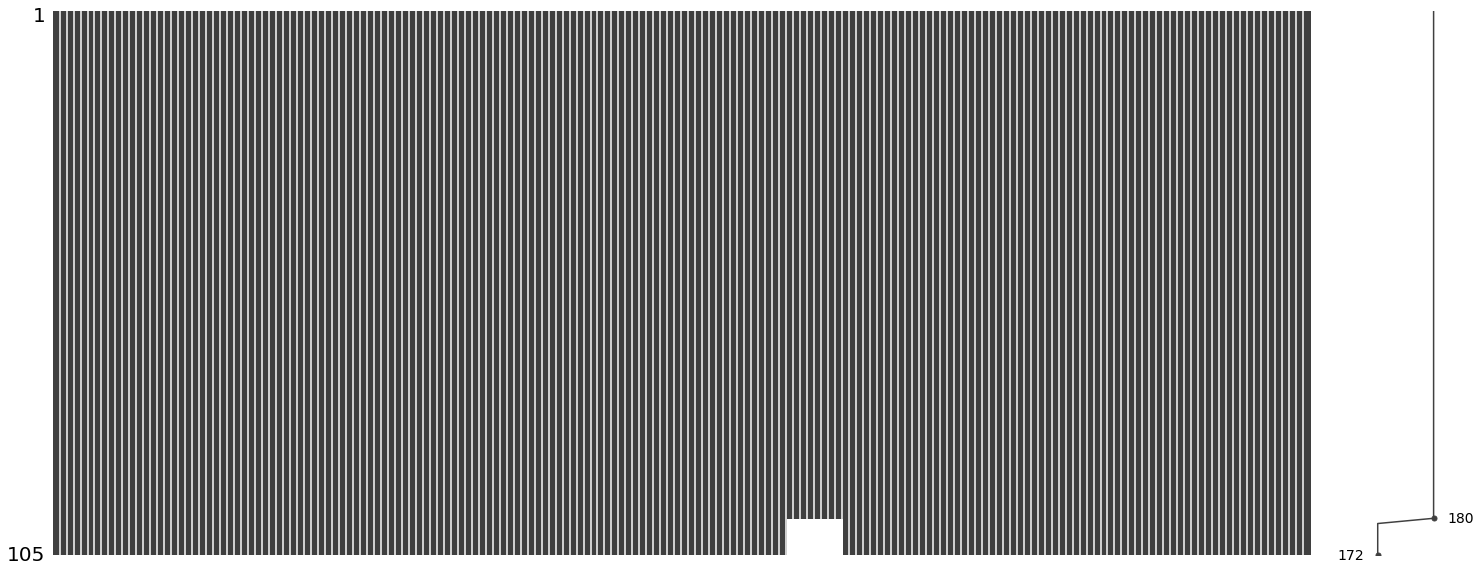

In [22]:
missingno.matrix(dataset_annual, label_rotation=90)

<AxesSubplot:>

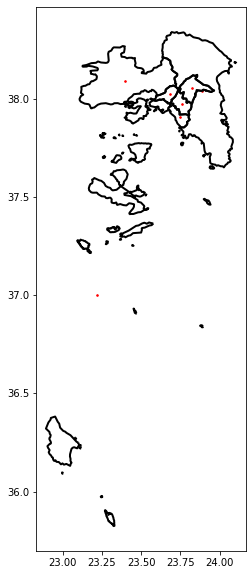

In [23]:
## Reading shapefiles from Greece

greece_nuts3_gdf = gpd.read_file(f"../../../../Europe NUTS - LAU/Greece/data/EL_Whole.shp",  encoding=enc)

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)

nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == f'{NUTS2_ID}']

nuts3_points = gpd.GeoDataFrame(dataset_annual[['NUTS3_NAME']], geometry=gpd.points_from_xy(dataset_annual.x, dataset_annual.y))

ax = nuts3_points.head(7).plot(markersize=2.5, figsize=(10, 10), color='red')
nuts3_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [24]:
data_q1 = []
data_q2 = []
data_q3 = []
data_q4 = []

for year in years[1:]:
    for region in nuts3_units:

        df_preceding = dataset_annual.loc[(dataset_annual['year'] == year-1) & (dataset_annual['NUTS3_NAME'] == region)]
        df_current = dataset_annual.loc[(dataset_annual['year'] == year) & (dataset_annual['NUTS3_NAME'] == region)]

        data_q1.append({'year': year, 
                        'NUTS2_ID':df_current.NUTS2_ID.iloc[0],
                        'NUTS2_NAME': df_current.NUTS2_NAME.iloc[0],
                        'NUTS3_ID':df_current.NUTS3_ID.iloc[0],
                        'NUTS3_NAME': region,
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q1': df_current.min_temp_q1.iloc[0],
                        'mean_temp_q1': df_current.mean_temp_q1.iloc[0],
                        'max_temp_q1': df_current.max_temp_q1.iloc[0],
                        'prec_q1': df_current.prec_q1.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q1': df_current.ndvi_q1.iloc[0],
                        'ndwi_q1': df_current.ndwi_q1.iloc[0],
                        'ndmi_q1': df_current.ndmi_q1.iloc[0],
                        'ndbi_q1': df_current.ndbi_q1.iloc[0],
                        'ndvi_mean_q1': df_current.ndvi_mean_q1.iloc[0],
                        'ndwi_mean_q1': df_current.ndwi_mean_q1.iloc[0],
                        'ndmi_mean_q1': df_current.ndmi_mean_q1.iloc[0],
                        'ndbi_mean_q1': df_current.ndbi_mean_q1.iloc[0],
                        'ndvi_std_q1': df_current.ndvi_std_q1.iloc[0],
                        'ndwi_std_q1': df_current.ndwi_std_q1.iloc[0],
                        'ndmi_std_q1': df_current.ndmi_std_q1.iloc[0],
                        'ndbi_std_q1': df_current.ndbi_std_q1.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'distance_to_coast': df_preceding.distance_to_coast.iloc[0],
                        'distance_to_river': df_preceding.distance_to_river.iloc[0],
                        'slope_mean_1km': df_preceding.slope_mean_1km.iloc[0],
                        'aspect_mean_200m': df_preceding.aspect_mean_200m.iloc[0],
                        'elevation_mean_1km': df_preceding.elevation_mean_1km.iloc[0],
                        'hillshade_mean_1km': df_preceding.hillshade_mean_1km.iloc[0],
                        'fs_area_1km': df_preceding.fs_area_1km.iloc[0],
                        'flow_accu_200m': df_preceding.flow_accu_200m.iloc[0],
                        'lc_prop1': df_preceding.lc_prop1.iloc[0],
                        'lc_prop2': df_preceding.lc_prop2.iloc[0],                    
                        'lc_prop3': df_preceding.lc_prop3.iloc[0],
                        'lc_type1': df_preceding.lc_type1.iloc[0],
                        'lc_type2': df_preceding.lc_type2.iloc[0],
                        'lc_type3': df_preceding.lc_type3.iloc[0],
                        'lc_type4': df_preceding.lc_type4.iloc[0],
                        'lc_type5': df_preceding.lc_type5.iloc[0],
                        'lw': df_preceding.lw.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred_mean.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
        data_q2.append({'year': year, 
                        'NUTS2_ID':df_current.NUTS2_ID.iloc[0],
                        'NUTS2_NAME': df_current.NUTS2_NAME.iloc[0],
                        'NUTS3_ID':df_current.NUTS3_ID.iloc[0],
                        'NUTS3_NAME': region,
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q2': df_current.min_temp_q2.iloc[0],
                        'mean_temp_q2': df_current.mean_temp_q2.iloc[0],
                        'max_temp_q2': df_current.max_temp_q2.iloc[0],
                        'prec_q2': df_current.prec_q2.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q2': df_current.ndvi_q2.iloc[0],
                        'ndwi_q2': df_current.ndwi_q2.iloc[0],
                        'ndmi_q2': df_current.ndmi_q2.iloc[0],
                        'ndbi_q2': df_current.ndbi_q2.iloc[0],
                        'ndvi_mean_q2': df_current.ndvi_mean_q2.iloc[0],
                        'ndwi_mean_q2': df_current.ndwi_mean_q2.iloc[0],
                        'ndmi_mean_q2': df_current.ndmi_mean_q2.iloc[0],
                        'ndbi_mean_q2': df_current.ndbi_mean_q2.iloc[0],
                        'ndvi_std_q2': df_current.ndvi_std_q2.iloc[0],
                        'ndwi_std_q2': df_current.ndwi_std_q2.iloc[0],
                        'ndmi_std_q2': df_current.ndmi_std_q2.iloc[0],
                        'ndbi_std_q2': df_current.ndbi_std_q2.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'distance_to_coast': df_preceding.distance_to_coast.iloc[0],
                        'distance_to_river': df_preceding.distance_to_river.iloc[0],
                        'slope_mean_1km': df_preceding.slope_mean_1km.iloc[0],
                        'aspect_mean_200m': df_preceding.aspect_mean_200m.iloc[0],
                        'elevation_mean_1km': df_preceding.elevation_mean_1km.iloc[0],
                        'hillshade_mean_1km': df_preceding.hillshade_mean_1km.iloc[0],
                        'fs_area_1km': df_preceding.fs_area_1km.iloc[0],
                        'flow_accu_200m': df_preceding.flow_accu_200m.iloc[0],
                        'lc_prop1': df_preceding.lc_prop1.iloc[0],
                        'lc_prop2': df_preceding.lc_prop2.iloc[0],                    
                        'lc_prop3': df_preceding.lc_prop3.iloc[0],
                        'lc_type1': df_preceding.lc_type1.iloc[0],
                        'lc_type2': df_preceding.lc_type2.iloc[0],
                        'lc_type3': df_preceding.lc_type3.iloc[0],
                        'lc_type4': df_preceding.lc_type4.iloc[0],
                        'lc_type5': df_preceding.lc_type5.iloc[0],
                        'lw': df_preceding.lw.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred_mean.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
        data_q3.append({'year': year, 
                        'NUTS2_ID':df_current.NUTS2_ID.iloc[0],
                        'NUTS2_NAME': df_current.NUTS2_NAME.iloc[0],
                        'NUTS3_ID':df_current.NUTS3_ID.iloc[0],
                        'NUTS3_NAME': region,
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q3': df_current.min_temp_q3.iloc[0],
                        'mean_temp_q3': df_current.mean_temp_q3.iloc[0],
                        'max_temp_q3': df_current.max_temp_q3.iloc[0],
                        'prec_q3': df_current.prec_q3.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q3': df_current.ndvi_q3.iloc[0],
                        'ndwi_q3': df_current.ndwi_q3.iloc[0],
                        'ndmi_q3': df_current.ndmi_q3.iloc[0],
                        'ndbi_q3': df_current.ndbi_q3.iloc[0],
                        'ndvi_mean_q3': df_current.ndvi_mean_q3.iloc[0],
                        'ndwi_mean_q3': df_current.ndwi_mean_q3.iloc[0],
                        'ndmi_mean_q3': df_current.ndmi_mean_q3.iloc[0],
                        'ndbi_mean_q3': df_current.ndbi_mean_q3.iloc[0],
                        'ndvi_std_q3': df_current.ndvi_std_q3.iloc[0],
                        'ndwi_std_q3': df_current.ndwi_std_q3.iloc[0],
                        'ndmi_std_q3': df_current.ndmi_std_q3.iloc[0],
                        'ndbi_std_q3': df_current.ndbi_std_q3.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'distance_to_coast': df_preceding.distance_to_coast.iloc[0],
                        'distance_to_river': df_preceding.distance_to_river.iloc[0],
                        'slope_mean_1km': df_preceding.slope_mean_1km.iloc[0],
                        'aspect_mean_200m': df_preceding.aspect_mean_200m.iloc[0],
                        'elevation_mean_1km': df_preceding.elevation_mean_1km.iloc[0],
                        'hillshade_mean_1km': df_preceding.hillshade_mean_1km.iloc[0],
                        'fs_area_1km': df_preceding.fs_area_1km.iloc[0],
                        'flow_accu_200m': df_preceding.flow_accu_200m.iloc[0],
                        'lc_prop1': df_preceding.lc_prop1.iloc[0],
                        'lc_prop2': df_preceding.lc_prop2.iloc[0],                    
                        'lc_prop3': df_preceding.lc_prop3.iloc[0],
                        'lc_type1': df_preceding.lc_type1.iloc[0],
                        'lc_type2': df_preceding.lc_type2.iloc[0],
                        'lc_type3': df_preceding.lc_type3.iloc[0],
                        'lc_type4': df_preceding.lc_type4.iloc[0],
                        'lc_type5': df_preceding.lc_type5.iloc[0],
                        'lw': df_preceding.lw.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred_mean.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
        data_q4.append({'year': year, 
                        'NUTS2_ID':df_current.NUTS2_ID.iloc[0],
                        'NUTS2_NAME': df_current.NUTS2_NAME.iloc[0],
                        'NUTS3_ID':df_current.NUTS3_ID.iloc[0],
                        'NUTS3_NAME': region,
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q4': df_current.min_temp_q4.iloc[0],
                        'mean_temp_q4': df_current.mean_temp_q4.iloc[0],
                        'max_temp_q4': df_current.max_temp_q4.iloc[0],
                        'prec_q4': df_current.prec_q4.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q4': df_current.ndvi_q4.iloc[0],
                        'ndwi_q4': df_current.ndwi_q4.iloc[0],
                        'ndmi_q4': df_current.ndmi_q4.iloc[0],
                        'ndbi_q4': df_current.ndbi_q4.iloc[0],
                        'ndvi_mean_q4': df_current.ndvi_mean_q4.iloc[0],
                        'ndwi_mean_q4': df_current.ndwi_mean_q4.iloc[0],
                        'ndmi_mean_q4': df_current.ndmi_mean_q4.iloc[0],
                        'ndbi_mean_q4': df_current.ndbi_mean_q4.iloc[0],
                        'ndvi_std_q4': df_current.ndvi_std_q4.iloc[0],
                        'ndwi_std_q4': df_current.ndwi_std_q4.iloc[0],
                        'ndmi_std_q4': df_current.ndmi_std_q4.iloc[0],
                        'ndbi_std_q4': df_current.ndbi_std_q4.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'distance_to_coast': df_preceding.distance_to_coast.iloc[0],
                        'distance_to_river': df_preceding.distance_to_river.iloc[0],
                        'slope_mean_1km': df_preceding.slope_mean_1km.iloc[0],
                        'aspect_mean_200m': df_preceding.aspect_mean_200m.iloc[0],
                        'elevation_mean_1km': df_preceding.elevation_mean_1km.iloc[0],
                        'hillshade_mean_1km': df_preceding.hillshade_mean_1km.iloc[0],
                        'fs_area_1km': df_preceding.fs_area_1km.iloc[0],
                        'flow_accu_200m': df_preceding.flow_accu_200m.iloc[0],
                        'lc_prop1': df_preceding.lc_prop1.iloc[0],
                        'lc_prop2': df_preceding.lc_prop2.iloc[0],                    
                        'lc_prop3': df_preceding.lc_prop3.iloc[0],
                        'lc_type1': df_preceding.lc_type1.iloc[0],
                        'lc_type2': df_preceding.lc_type2.iloc[0],
                        'lc_type3': df_preceding.lc_type3.iloc[0],
                        'lc_type4': df_preceding.lc_type4.iloc[0],
                        'lc_type5': df_preceding.lc_type5.iloc[0],
                        'lw': df_preceding.lw.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred_mean.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
df_q1 = pd.DataFrame(data_q1)
df_q2 = pd.DataFrame(data_q2)   
df_q3 = pd.DataFrame(data_q3)   
df_q4 = pd.DataFrame(data_q4)   

In [25]:
df_q1

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,8.382452,10.930627,14.246645,10.456486,19.000000,19.166667,42.592593,920.721061,45.0,0.0,45.0,8.333333,30.666667,30.666667,8.333333,1230.0,227.0,9.0,72.351252,546.0,54.0,54.0,546.0,0.226451,-0.126134,0.098249,-0.098249,0.228782,-0.130680,0.096930,-0.096930,0.031359,0.022289,0.021538,0.021538,293201.0,45632.0,201617.0,45952.0,322694.0,43321.0,220852.0,58521.0,19823.630,2605.2,3841.2,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,22.0,9.0,20.0,13.0,13.0,10.0,8.0,9.0,2.0,227.211331,0
1,2010,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,10.596452,12.635540,16.155097,10.155818,20.791667,18.916667,42.992424,928.453830,46.0,2.0,44.0,9.833333,33.000000,33.000000,9.833333,1216.0,229.0,10.0,72.746381,538.0,55.0,55.0,538.0,0.113877,-0.099892,0.039683,-0.039683,0.136003,-0.105539,0.049818,-0.049818,0.037803,0.019016,0.017592,0.017592,252725.0,39132.0,180473.0,33120.0,258571.0,36806.0,177964.0,43801.0,7725.120,2605.2,3841.2,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,1.0,9.0,1.0,13.0,13.0,10.0,8.0,9.0,2.0,374.654117,0
2,2010,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,9.811968,12.146278,15.378581,10.248108,19.875000,18.250000,43.452381,879.081390,44.0,2.0,42.0,9.833333,31.333333,31.333333,9.833333,1175.0,208.0,5.0,73.228177,521.0,47.0,47.0,521.0,0.153955,-0.055119,0.089710,-0.089710,0.167917,-0.064474,0.093489,-0.093489,0.044527,0.026543,0.028139,0.028139,528902.0,65801.0,384275.0,78826.0,575205.0,62294.0,394771.0,118140.0,42230.540,2605.2,3841.2,7451.460209,1907.131239,7.200000,218.497003,207.330391,190.939862,0.000000,2.773017,1.0,9.0,1.0,13.0,13.0,10.0,8.0,9.0,2.0,314.844209,0
3,2010,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.745366,37.906427,9.466083,12.279492,15.942903,10.042250,19.291667,18.250000,42.441860,874.761872,43.0,0.0,43.0,9.666667,30.666667,30.666667,9.333333,1156.0,200.0,3.0,74.022313,512.0,41.0,41.0,456.0,0.174020,-0.103821,0.081353,-0.081353,0.169634,-0.105575,0.077146,-0.077146,0.032255,0.018364,0.016616,0.016616,264029.0,39069.0,184842.0,40118.0,291026.0,36883.0,199704.0,54439.0,13339.200,2605.2,3841.2,2626.770961,1089.712354,6.285714,221.663863,97.544439,189.577626,0.000000,5.864646,32.0,9.0,30.0,13.0,13.0,10.0,8.0,9.0,2.0,344.022866,0
4,2010,EL30,αττικη,EL305,ανατολικη αττικη,23.886562,38.040564,8.679107,10.669523,13.702702,10.553940,18.708333,19.916667,44.259259,885.093301,45.0,0.0,45.0,9.000000,29.833333,29.833333,8.333333,1231.0,223.0,7.0,72.756797,539.0,47.0,47.0,467.0,0.379141,-0.203849,0.146448,-0.146448,0.377125,-0.200583,0.147239,-0.147239,0.033895,0.032306,0.032192,0.032192,252569.0,41876.0,176906.0,33787.0,244380.0,39627.0,167626.0,37127.0,13475.350,2605.2,3841.2,5611.983975,1700.571082,9.356902,167.034553,251.967998,178.128437,0.004394,36.564396,31.0,30.0,30.0,10.0,10.0,1.0,6.0,6.0,2.0,207.316244,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,2023,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,9.496857,11.423684,13.917677,9

In [26]:
df_q2

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,8.382452,17.178349,28.661644,14.195797,19.000000,19.166667,42.592593,920.721061,45.0,0.0,45.0,8.333333,30.666667,30.666667,8.333333,1230.0,227.0,9.0,72.351252,546.0,54.0,54.0,546.0,0.230666,-0.169994,0.077793,-0.077793,0.233112,-0.173877,0.077089,-0.077089,0.028104,0.022192,0.019907,0.019907,293201.0,45632.0,201617.0,45952.0,322694.0,43321.0,220852.0,58521.0,19823.630,2605.2,3841.2,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,22.0,9.0,20.0,13.0,13.0,10.0,8.0,9.0,2.0,227.211331,0
1,2010,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,10.596452,18.975166,30.350133,13.584063,20.791667,18.916667,42.992424,928.453830,46.0,2.0,44.0,9.833333,33.000000,33.000000,9.833333,1216.0,229.0,10.0,72.746381,538.0,55.0,55.0,538.0,0.117205,-0.136204,0.022498,-0.022498,0.135648,-0.145112,0.028097,-0.028097,0.030594,0.020591,0.014386,0.014386,252725.0,39132.0,180473.0,33120.0,258571.0,36806.0,177964.0,43801.0,7725.120,2605.2,3841.2,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,1.0,9.0,1.0,13.0,13.0,10.0,8.0,9.0,2.0,374.654117,0
2,2010,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,9.811968,18.194361,29.345967,13.475604,19.875000,18.250000,43.452381,879.081390,44.0,2.0,42.0,9.833333,31.333333,31.333333,9.833333,1175.0,208.0,5.0,73.228177,521.0,47.0,47.0,521.0,0.168038,-0.112506,0.063534,-0.063534,0.173404,-0.113205,0.067654,-0.067654,0.039023,0.025009,0.025365,0.025365,528902.0,65801.0,384275.0,78826.0,575205.0,62294.0,394771.0,118140.0,42230.540,2605.2,3841.2,7451.460209,1907.131239,7.200000,218.497003,207.330391,190.939862,0.000000,2.773017,1.0,9.0,1.0,13.0,13.0,10.0,8.0,9.0,2.0,314.844209,0
3,2010,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.745366,37.906427,9.466083,18.295804,29.234905,13.095614,19.291667,18.250000,42.441860,874.761872,43.0,0.0,43.0,9.666667,30.666667,30.666667,9.333333,1156.0,200.0,3.0,74.022313,512.0,41.0,41.0,456.0,0.164187,-0.145565,0.050006,-0.050006,0.160413,-0.144168,0.047861,-0.047861,0.023864,0.018140,0.014056,0.014056,264029.0,39069.0,184842.0,40118.0,291026.0,36883.0,199704.0,54439.0,13339.200,2605.2,3841.2,2626.770961,1089.712354,6.285714,221.663863,97.544439,189.577626,0.000000,5.864646,32.0,9.0,30.0,13.0,13.0,10.0,8.0,9.0,2.0,344.022866,0
4,2010,EL30,αττικη,EL305,ανατολικη αττικη,23.886562,38.040564,8.679107,16.590767,27.645846,14.434491,18.708333,19.916667,44.259259,885.093301,45.0,0.0,45.0,9.000000,29.833333,29.833333,8.333333,1231.0,223.0,7.0,72.756797,539.0,47.0,47.0,467.0,0.362681,-0.255706,0.104786,-0.104786,0.359552,-0.250768,0.105737,-0.105737,0.033033,0.028890,0.030963,0.030963,252569.0,41876.0,176906.0,33787.0,244380.0,39627.0,167626.0,37127.0,13475.350,2605.2,3841.2,5611.983975,1700.571082,9.356902,167.034553,251.967998,178.128437,0.004394,36.564396,31.0,30.0,30.0,10.0,10.0,1.0,6.0,6.0,2.0,207.316244,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,2023,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,9.496857,16.999983,28.353200,1

In [27]:
df_q3

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,8.382452,21.102718,31.459527,16.758503,19.000000,19.166667,42.592593,920.721061,45.0,0.0,45.0,8.333333,30.666667,30.666667,8.333333,1230.0,227.0,9.0,72.351252,546.0,54.0,54.0,546.0,0.227160,-0.176551,0.070153,-0.070153,0.228785,-0.181078,0.068171,-0.068171,0.027449,0.023303,0.020835,0.020835,293201.0,45632.0,201617.0,45952.0,322694.0,43321.0,220852.0,58521.0,19823.630,2605.2,3841.2,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,22.0,9.0,20.0,13.0,13.0,10.0,8.0,9.0,2.0,227.211331,0
1,2010,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,10.596452,23.034186,33.519935,16.405771,20.791667,18.916667,42.992424,928.453830,46.0,2.0,44.0,9.833333,33.000000,33.000000,9.833333,1216.0,229.0,10.0,72.746381,538.0,55.0,55.0,538.0,0.114180,-0.137378,0.018614,-0.018614,0.130310,-0.152855,0.018061,-0.018061,0.025438,0.018739,0.012590,0.012590,252725.0,39132.0,180473.0,33120.0,258571.0,36806.0,177964.0,43801.0,7725.120,2605.2,3841.2,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,1.0,9.0,1.0,13.0,13.0,10.0,8.0,9.0,2.0,374.654117,0
2,2010,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,9.811968,22.101970,32.419645,15.959792,19.875000,18.250000,43.452381,879.081390,44.0,2.0,42.0,9.833333,31.333333,31.333333,9.833333,1175.0,208.0,5.0,73.228177,521.0,47.0,47.0,521.0,0.159301,-0.117995,0.053382,-0.053382,0.164446,-0.114166,0.060021,-0.060021,0.037209,0.026495,0.023819,0.023819,528902.0,65801.0,384275.0,78826.0,575205.0,62294.0,394771.0,118140.0,42230.540,2605.2,3841.2,7451.460209,1907.131239,7.200000,218.497003,207.330391,190.939862,0.000000,2.773017,1.0,9.0,1.0,13.0,13.0,10.0,8.0,9.0,2.0,314.844209,0
3,2010,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.745366,37.906427,9.466083,22.229094,32.568479,15.634951,19.291667,18.250000,42.441860,874.761872,43.0,0.0,43.0,9.666667,30.666667,30.666667,9.333333,1156.0,200.0,3.0,74.022313,512.0,41.0,41.0,456.0,0.153073,-0.147553,0.039736,-0.039736,0.150307,-0.143872,0.039934,-0.039934,0.023406,0.023935,0.016382,0.016382,264029.0,39069.0,184842.0,40118.0,291026.0,36883.0,199704.0,54439.0,13339.200,2605.2,3841.2,2626.770961,1089.712354,6.285714,221.663863,97.544439,189.577626,0.000000,5.864646,32.0,9.0,30.0,13.0,13.0,10.0,8.0,9.0,2.0,344.022866,0
4,2010,EL30,αττικη,EL305,ανατολικη αττικη,23.886562,38.040564,8.679107,20.598661,30.996366,16.976485,18.708333,19.916667,44.259259,885.093301,45.0,0.0,45.0,9.000000,29.833333,29.833333,8.333333,1231.0,223.0,7.0,72.756797,539.0,47.0,47.0,467.0,0.331467,-0.260147,0.076773,-0.076773,0.329480,-0.256010,0.078085,-0.078085,0.031514,0.028265,0.029983,0.029983,252569.0,41876.0,176906.0,33787.0,244380.0,39627.0,167626.0,37127.0,13475.350,2605.2,3841.2,5611.983975,1700.571082,9.356902,167.034553,251.967998,178.128437,0.004394,36.564396,31.0,30.0,30.0,10.0,10.0,1.0,6.0,6.0,2.0,207.316244,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,2023,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,9.496857,21.869712,34.137903,1

In [28]:
df_q4

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,8.382452,19.553343,31.459527,28.141445,19.000000,19.166667,42.592593,920.721061,45.0,0.0,45.0,8.333333,30.666667,30.666667,8.333333,1230.0,227.0,9.0,72.351252,546.0,54.0,54.0,546.0,0.217055,-0.143551,0.082194,-0.082194,0.215502,-0.144651,0.080280,-0.080280,0.026474,0.024663,0.020635,0.020635,293201.0,45632.0,201617.0,45952.0,322694.0,43321.0,220852.0,58521.0,19823.630,2605.2,3841.2,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,22.0,9.0,20.0,13.0,13.0,10.0,8.0,9.0,2.0,227.211331,0
1,2010,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,10.596452,21.264301,33.519935,27.109826,20.791667,18.916667,42.992424,928.453830,46.0,2.0,44.0,9.833333,33.000000,33.000000,9.833333,1216.0,229.0,10.0,72.746381,538.0,55.0,55.0,538.0,0.111912,-0.138258,0.015701,-0.015701,0.134883,-0.143830,0.023054,-0.023054,0.020313,0.015453,0.010560,0.010560,252725.0,39132.0,180473.0,33120.0,258571.0,36806.0,177964.0,43801.0,7725.120,2605.2,3841.2,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,1.0,9.0,1.0,13.0,13.0,10.0,8.0,9.0,2.0,374.654117,0
2,2010,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,9.811968,20.504824,32.419645,26.384668,19.875000,18.250000,43.452381,879.081390,44.0,2.0,42.0,9.833333,31.333333,31.333333,9.833333,1175.0,208.0,5.0,73.228177,521.0,47.0,47.0,521.0,0.146979,-0.092774,0.060723,-0.060723,0.153007,-0.088169,0.068069,-0.068069,0.036936,0.030339,0.025330,0.025330,528902.0,65801.0,384275.0,78826.0,575205.0,62294.0,394771.0,118140.0,42230.540,2605.2,3841.2,7451.460209,1907.131239,7.200000,218.497003,207.330391,190.939862,0.000000,2.773017,1.0,9.0,1.0,13.0,13.0,10.0,8.0,9.0,2.0,314.844209,0
3,2010,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.745366,37.906427,9.466083,20.615073,32.568479,25.862544,19.291667,18.250000,42.441860,874.761872,43.0,0.0,43.0,9.666667,30.666667,30.666667,9.333333,1156.0,200.0,3.0,74.022313,512.0,41.0,41.0,456.0,0.142935,-0.118326,0.049905,-0.049905,0.142779,-0.112115,0.053354,-0.053354,0.024744,0.027047,0.017728,0.017728,264029.0,39069.0,184842.0,40118.0,291026.0,36883.0,199704.0,54439.0,13339.200,2605.2,3841.2,2626.770961,1089.712354,6.285714,221.663863,97.544439,189.577626,0.000000,5.864646,32.0,9.0,30.0,13.0,13.0,10.0,8.0,9.0,2.0,344.022866,0
4,2010,EL30,αττικη,EL305,ανατολικη αττικη,23.886562,38.040564,8.679107,19.112438,30.996366,28.794685,18.708333,19.916667,44.259259,885.093301,45.0,0.0,45.0,9.000000,29.833333,29.833333,8.333333,1231.0,223.0,7.0,72.756797,539.0,47.0,47.0,467.0,0.308666,-0.222241,0.084526,-0.084526,0.305396,-0.216340,0.085710,-0.085710,0.029795,0.030716,0.028941,0.028941,252569.0,41876.0,176906.0,33787.0,244380.0,39627.0,167626.0,37127.0,13475.350,2605.2,3841.2,5611.983975,1700.571082,9.356902,167.034553,251.967998,178.128437,0.004394,36.564396,31.0,30.0,30.0,10.0,10.0,1.0,6.0,6.0,2.0,207.316244,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,2023,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,9.496857,21.878915,34.137903,1

In [29]:
print(df_q1.WNV_cases.sum())
print(df_q2.WNV_cases.sum())
print(df_q3.WNV_cases.sum())
print(df_q4.WNV_cases.sum())

296
296
296
296


In [30]:
print(df_q1.WNV_cases.sum())
print(df_q2.WNV_cases.sum())
print(df_q3.WNV_cases.sum())
print(df_q4.WNV_cases.sum())

296
296
296
296


In [31]:
df_q1

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,8.382452,10.930627,14.246645,10.456486,19.000000,19.166667,42.592593,920.721061,45.0,0.0,45.0,8.333333,30.666667,30.666667,8.333333,1230.0,227.0,9.0,72.351252,546.0,54.0,54.0,546.0,0.226451,-0.126134,0.098249,-0.098249,0.228782,-0.130680,0.096930,-0.096930,0.031359,0.022289,0.021538,0.021538,293201.0,45632.0,201617.0,45952.0,322694.0,43321.0,220852.0,58521.0,19823.630,2605.2,3841.2,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,22.0,9.0,20.0,13.0,13.0,10.0,8.0,9.0,2.0,227.211331,0
1,2010,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,10.596452,12.635540,16.155097,10.155818,20.791667,18.916667,42.992424,928.453830,46.0,2.0,44.0,9.833333,33.000000,33.000000,9.833333,1216.0,229.0,10.0,72.746381,538.0,55.0,55.0,538.0,0.113877,-0.099892,0.039683,-0.039683,0.136003,-0.105539,0.049818,-0.049818,0.037803,0.019016,0.017592,0.017592,252725.0,39132.0,180473.0,33120.0,258571.0,36806.0,177964.0,43801.0,7725.120,2605.2,3841.2,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,1.0,9.0,1.0,13.0,13.0,10.0,8.0,9.0,2.0,374.654117,0
2,2010,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,9.811968,12.146278,15.378581,10.248108,19.875000,18.250000,43.452381,879.081390,44.0,2.0,42.0,9.833333,31.333333,31.333333,9.833333,1175.0,208.0,5.0,73.228177,521.0,47.0,47.0,521.0,0.153955,-0.055119,0.089710,-0.089710,0.167917,-0.064474,0.093489,-0.093489,0.044527,0.026543,0.028139,0.028139,528902.0,65801.0,384275.0,78826.0,575205.0,62294.0,394771.0,118140.0,42230.540,2605.2,3841.2,7451.460209,1907.131239,7.200000,218.497003,207.330391,190.939862,0.000000,2.773017,1.0,9.0,1.0,13.0,13.0,10.0,8.0,9.0,2.0,314.844209,0
3,2010,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.745366,37.906427,9.466083,12.279492,15.942903,10.042250,19.291667,18.250000,42.441860,874.761872,43.0,0.0,43.0,9.666667,30.666667,30.666667,9.333333,1156.0,200.0,3.0,74.022313,512.0,41.0,41.0,456.0,0.174020,-0.103821,0.081353,-0.081353,0.169634,-0.105575,0.077146,-0.077146,0.032255,0.018364,0.016616,0.016616,264029.0,39069.0,184842.0,40118.0,291026.0,36883.0,199704.0,54439.0,13339.200,2605.2,3841.2,2626.770961,1089.712354,6.285714,221.663863,97.544439,189.577626,0.000000,5.864646,32.0,9.0,30.0,13.0,13.0,10.0,8.0,9.0,2.0,344.022866,0
4,2010,EL30,αττικη,EL305,ανατολικη αττικη,23.886562,38.040564,8.679107,10.669523,13.702702,10.553940,18.708333,19.916667,44.259259,885.093301,45.0,0.0,45.0,9.000000,29.833333,29.833333,8.333333,1231.0,223.0,7.0,72.756797,539.0,47.0,47.0,467.0,0.379141,-0.203849,0.146448,-0.146448,0.377125,-0.200583,0.147239,-0.147239,0.033895,0.032306,0.032192,0.032192,252569.0,41876.0,176906.0,33787.0,244380.0,39627.0,167626.0,37127.0,13475.350,2605.2,3841.2,5611.983975,1700.571082,9.356902,167.034553,251.967998,178.128437,0.004394,36.564396,31.0,30.0,30.0,10.0,10.0,1.0,6.0,6.0,2.0,207.316244,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,2023,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,9.496857,11.423684,13.917677,9

In [32]:
df_q2

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,8.382452,17.178349,28.661644,14.195797,19.000000,19.166667,42.592593,920.721061,45.0,0.0,45.0,8.333333,30.666667,30.666667,8.333333,1230.0,227.0,9.0,72.351252,546.0,54.0,54.0,546.0,0.230666,-0.169994,0.077793,-0.077793,0.233112,-0.173877,0.077089,-0.077089,0.028104,0.022192,0.019907,0.019907,293201.0,45632.0,201617.0,45952.0,322694.0,43321.0,220852.0,58521.0,19823.630,2605.2,3841.2,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,22.0,9.0,20.0,13.0,13.0,10.0,8.0,9.0,2.0,227.211331,0
1,2010,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,10.596452,18.975166,30.350133,13.584063,20.791667,18.916667,42.992424,928.453830,46.0,2.0,44.0,9.833333,33.000000,33.000000,9.833333,1216.0,229.0,10.0,72.746381,538.0,55.0,55.0,538.0,0.117205,-0.136204,0.022498,-0.022498,0.135648,-0.145112,0.028097,-0.028097,0.030594,0.020591,0.014386,0.014386,252725.0,39132.0,180473.0,33120.0,258571.0,36806.0,177964.0,43801.0,7725.120,2605.2,3841.2,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,1.0,9.0,1.0,13.0,13.0,10.0,8.0,9.0,2.0,374.654117,0
2,2010,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,9.811968,18.194361,29.345967,13.475604,19.875000,18.250000,43.452381,879.081390,44.0,2.0,42.0,9.833333,31.333333,31.333333,9.833333,1175.0,208.0,5.0,73.228177,521.0,47.0,47.0,521.0,0.168038,-0.112506,0.063534,-0.063534,0.173404,-0.113205,0.067654,-0.067654,0.039023,0.025009,0.025365,0.025365,528902.0,65801.0,384275.0,78826.0,575205.0,62294.0,394771.0,118140.0,42230.540,2605.2,3841.2,7451.460209,1907.131239,7.200000,218.497003,207.330391,190.939862,0.000000,2.773017,1.0,9.0,1.0,13.0,13.0,10.0,8.0,9.0,2.0,314.844209,0
3,2010,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.745366,37.906427,9.466083,18.295804,29.234905,13.095614,19.291667,18.250000,42.441860,874.761872,43.0,0.0,43.0,9.666667,30.666667,30.666667,9.333333,1156.0,200.0,3.0,74.022313,512.0,41.0,41.0,456.0,0.164187,-0.145565,0.050006,-0.050006,0.160413,-0.144168,0.047861,-0.047861,0.023864,0.018140,0.014056,0.014056,264029.0,39069.0,184842.0,40118.0,291026.0,36883.0,199704.0,54439.0,13339.200,2605.2,3841.2,2626.770961,1089.712354,6.285714,221.663863,97.544439,189.577626,0.000000,5.864646,32.0,9.0,30.0,13.0,13.0,10.0,8.0,9.0,2.0,344.022866,0
4,2010,EL30,αττικη,EL305,ανατολικη αττικη,23.886562,38.040564,8.679107,16.590767,27.645846,14.434491,18.708333,19.916667,44.259259,885.093301,45.0,0.0,45.0,9.000000,29.833333,29.833333,8.333333,1231.0,223.0,7.0,72.756797,539.0,47.0,47.0,467.0,0.362681,-0.255706,0.104786,-0.104786,0.359552,-0.250768,0.105737,-0.105737,0.033033,0.028890,0.030963,0.030963,252569.0,41876.0,176906.0,33787.0,244380.0,39627.0,167626.0,37127.0,13475.350,2605.2,3841.2,5611.983975,1700.571082,9.356902,167.034553,251.967998,178.128437,0.004394,36.564396,31.0,30.0,30.0,10.0,10.0,1.0,6.0,6.0,2.0,207.316244,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,2023,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,9.496857,16.999983,28.353200,1

In [33]:
df_q3

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,8.382452,21.102718,31.459527,16.758503,19.000000,19.166667,42.592593,920.721061,45.0,0.0,45.0,8.333333,30.666667,30.666667,8.333333,1230.0,227.0,9.0,72.351252,546.0,54.0,54.0,546.0,0.227160,-0.176551,0.070153,-0.070153,0.228785,-0.181078,0.068171,-0.068171,0.027449,0.023303,0.020835,0.020835,293201.0,45632.0,201617.0,45952.0,322694.0,43321.0,220852.0,58521.0,19823.630,2605.2,3841.2,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,22.0,9.0,20.0,13.0,13.0,10.0,8.0,9.0,2.0,227.211331,0
1,2010,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,10.596452,23.034186,33.519935,16.405771,20.791667,18.916667,42.992424,928.453830,46.0,2.0,44.0,9.833333,33.000000,33.000000,9.833333,1216.0,229.0,10.0,72.746381,538.0,55.0,55.0,538.0,0.114180,-0.137378,0.018614,-0.018614,0.130310,-0.152855,0.018061,-0.018061,0.025438,0.018739,0.012590,0.012590,252725.0,39132.0,180473.0,33120.0,258571.0,36806.0,177964.0,43801.0,7725.120,2605.2,3841.2,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,1.0,9.0,1.0,13.0,13.0,10.0,8.0,9.0,2.0,374.654117,0
2,2010,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,9.811968,22.101970,32.419645,15.959792,19.875000,18.250000,43.452381,879.081390,44.0,2.0,42.0,9.833333,31.333333,31.333333,9.833333,1175.0,208.0,5.0,73.228177,521.0,47.0,47.0,521.0,0.159301,-0.117995,0.053382,-0.053382,0.164446,-0.114166,0.060021,-0.060021,0.037209,0.026495,0.023819,0.023819,528902.0,65801.0,384275.0,78826.0,575205.0,62294.0,394771.0,118140.0,42230.540,2605.2,3841.2,7451.460209,1907.131239,7.200000,218.497003,207.330391,190.939862,0.000000,2.773017,1.0,9.0,1.0,13.0,13.0,10.0,8.0,9.0,2.0,314.844209,0
3,2010,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.745366,37.906427,9.466083,22.229094,32.568479,15.634951,19.291667,18.250000,42.441860,874.761872,43.0,0.0,43.0,9.666667,30.666667,30.666667,9.333333,1156.0,200.0,3.0,74.022313,512.0,41.0,41.0,456.0,0.153073,-0.147553,0.039736,-0.039736,0.150307,-0.143872,0.039934,-0.039934,0.023406,0.023935,0.016382,0.016382,264029.0,39069.0,184842.0,40118.0,291026.0,36883.0,199704.0,54439.0,13339.200,2605.2,3841.2,2626.770961,1089.712354,6.285714,221.663863,97.544439,189.577626,0.000000,5.864646,32.0,9.0,30.0,13.0,13.0,10.0,8.0,9.0,2.0,344.022866,0
4,2010,EL30,αττικη,EL305,ανατολικη αττικη,23.886562,38.040564,8.679107,20.598661,30.996366,16.976485,18.708333,19.916667,44.259259,885.093301,45.0,0.0,45.0,9.000000,29.833333,29.833333,8.333333,1231.0,223.0,7.0,72.756797,539.0,47.0,47.0,467.0,0.331467,-0.260147,0.076773,-0.076773,0.329480,-0.256010,0.078085,-0.078085,0.031514,0.028265,0.029983,0.029983,252569.0,41876.0,176906.0,33787.0,244380.0,39627.0,167626.0,37127.0,13475.350,2605.2,3841.2,5611.983975,1700.571082,9.356902,167.034553,251.967998,178.128437,0.004394,36.564396,31.0,30.0,30.0,10.0,10.0,1.0,6.0,6.0,2.0,207.316244,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,2023,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,9.496857,21.869712,34.137903,1

In [34]:
df_q4

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,8.382452,19.553343,31.459527,28.141445,19.000000,19.166667,42.592593,920.721061,45.0,0.0,45.0,8.333333,30.666667,30.666667,8.333333,1230.0,227.0,9.0,72.351252,546.0,54.0,54.0,546.0,0.217055,-0.143551,0.082194,-0.082194,0.215502,-0.144651,0.080280,-0.080280,0.026474,0.024663,0.020635,0.020635,293201.0,45632.0,201617.0,45952.0,322694.0,43321.0,220852.0,58521.0,19823.630,2605.2,3841.2,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,22.0,9.0,20.0,13.0,13.0,10.0,8.0,9.0,2.0,227.211331,0
1,2010,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,10.596452,21.264301,33.519935,27.109826,20.791667,18.916667,42.992424,928.453830,46.0,2.0,44.0,9.833333,33.000000,33.000000,9.833333,1216.0,229.0,10.0,72.746381,538.0,55.0,55.0,538.0,0.111912,-0.138258,0.015701,-0.015701,0.134883,-0.143830,0.023054,-0.023054,0.020313,0.015453,0.010560,0.010560,252725.0,39132.0,180473.0,33120.0,258571.0,36806.0,177964.0,43801.0,7725.120,2605.2,3841.2,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,1.0,9.0,1.0,13.0,13.0,10.0,8.0,9.0,2.0,374.654117,0
2,2010,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,9.811968,20.504824,32.419645,26.384668,19.875000,18.250000,43.452381,879.081390,44.0,2.0,42.0,9.833333,31.333333,31.333333,9.833333,1175.0,208.0,5.0,73.228177,521.0,47.0,47.0,521.0,0.146979,-0.092774,0.060723,-0.060723,0.153007,-0.088169,0.068069,-0.068069,0.036936,0.030339,0.025330,0.025330,528902.0,65801.0,384275.0,78826.0,575205.0,62294.0,394771.0,118140.0,42230.540,2605.2,3841.2,7451.460209,1907.131239,7.200000,218.497003,207.330391,190.939862,0.000000,2.773017,1.0,9.0,1.0,13.0,13.0,10.0,8.0,9.0,2.0,314.844209,0
3,2010,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.745366,37.906427,9.466083,20.615073,32.568479,25.862544,19.291667,18.250000,42.441860,874.761872,43.0,0.0,43.0,9.666667,30.666667,30.666667,9.333333,1156.0,200.0,3.0,74.022313,512.0,41.0,41.0,456.0,0.142935,-0.118326,0.049905,-0.049905,0.142779,-0.112115,0.053354,-0.053354,0.024744,0.027047,0.017728,0.017728,264029.0,39069.0,184842.0,40118.0,291026.0,36883.0,199704.0,54439.0,13339.200,2605.2,3841.2,2626.770961,1089.712354,6.285714,221.663863,97.544439,189.577626,0.000000,5.864646,32.0,9.0,30.0,13.0,13.0,10.0,8.0,9.0,2.0,344.022866,0
4,2010,EL30,αττικη,EL305,ανατολικη αττικη,23.886562,38.040564,8.679107,19.112438,30.996366,28.794685,18.708333,19.916667,44.259259,885.093301,45.0,0.0,45.0,9.000000,29.833333,29.833333,8.333333,1231.0,223.0,7.0,72.756797,539.0,47.0,47.0,467.0,0.308666,-0.222241,0.084526,-0.084526,0.305396,-0.216340,0.085710,-0.085710,0.029795,0.030716,0.028941,0.028941,252569.0,41876.0,176906.0,33787.0,244380.0,39627.0,167626.0,37127.0,13475.350,2605.2,3841.2,5611.983975,1700.571082,9.356902,167.034553,251.967998,178.128437,0.004394,36.564396,31.0,30.0,30.0,10.0,10.0,1.0,6.0,6.0,2.0,207.316244,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,2023,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,9.496857,21.878915,34.137903,1

In [35]:
df_q1.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q1_2010_2023.csv", encoding = enc, index = False)
df_q2.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q2_2010_2023.csv", encoding = enc, index = False)
df_q3.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q3_2010_2023.csv", encoding = enc, index = False)
df_q4.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q4_2010_2023.csv", encoding = enc, index = False)